In [1]:
import cv2
import numpy as np
import pandas as pd
import math
from PIL import Image
from IPython.display import display, clear_output

In [2]:
input_video_path = "two_channel.mp4"
output_csv_path = "double_results.csv"

In [3]:
# Video input/output
cap = cv2.VideoCapture(input_video_path)
if not cap.isOpened():
    print(f"Error: Could not open video {input_video_path}")
    exit()

# Per-run storage and counters
data_log = []
frame_count = 0
fps = cap.get(cv2.CAP_PROP_FPS) if cap.get(cv2.CAP_PROP_FPS) > 0 else 240

# Frame geometry
frame_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
cx, cy = frame_width // 2, frame_height // 2

# Display settings
display_every_n_frames = 10

# Crop window centered near the middle
window_size = 220
half_window = window_size // 2
x1 = cx - half_window
y1 = cy - half_window - 80
x2 = cx + half_window
y2 = cy + half_window - 80

# Brightness ROI in cropped frame (bottom-right)
roi_size = 50
prev_brightness = None
change_threshold = 10
brightness_frames = []

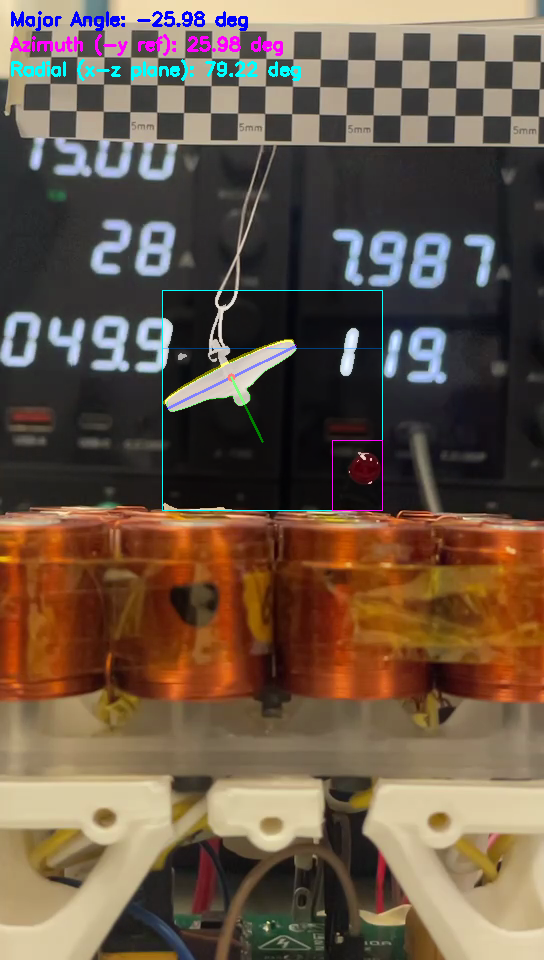

Frame 2641 | Major (2D): -25.95° | Minor Length (full): 45.62 px
  → rx (PCA major): 70.89, ry (PCA minor): 5.68, ratio: 0.0801, tilt: 85.4°
Frame 2642 | Major (2D): -26.05° | Minor Length (full): 45.62 px
  → rx (PCA major): 71.11, ry (PCA minor): 5.69, ratio: 0.0800, tilt: 85.4°
Frame 2643 | Major (2D): -26.10° | Minor Length (full): 45.62 px
  → rx (PCA major): 70.89, ry (PCA minor): 5.71, ratio: 0.0806, tilt: 85.4°
Frame 2644 | Major (2D): -26.13° | Minor Length (full): 45.16 px
  → rx (PCA major): 71.11, ry (PCA minor): 5.49, ratio: 0.0772, tilt: 85.6°

Intermediate results saved to: double_results.csv


In [4]:
while True:
    ret, frame = cap.read()
    if not ret:
        break

    frame_count += 1
    cropped = frame[y1:y2, x1:x2]

    # 1) Threshold the crop to isolate the bright object
    gray = cv2.cvtColor(cropped, cv2.COLOR_BGR2GRAY)
    _, binary = cv2.threshold(gray, 90, 255, cv2.THRESH_BINARY)

    # 2) Detect brightness-change events in the ROI
    h, w = binary.shape[:2]
    rx1, ry1 = max(w - roi_size, 0), max(h - roi_size - 20, 0)
    current_brightness = cv2.mean(binary[ry1:h, rx1:w])[0]
    if prev_brightness is not None and abs(prev_brightness - current_brightness) > change_threshold:
        print(f"Brightness drop detected at frame {frame_count}: {current_brightness:.2f}")
        brightness_frames.append(frame_count)
    prev_brightness = current_brightness

    # 3) Remove thin structures and keep the main blob
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (12, 12)) # kernal size 12x12
    clean_mask = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)
    contours, _ = cv2.findContours(clean_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    frame_data = {
        "frame": frame_count,
        "timestamp_sec": frame_count / fps,
        "detected": False,
        "radial_angle_deg": None,
        "azimuthal_angle_deg": None,
    }
    overlay = frame.copy()

    if contours:
        best_cnt = max(contours, key=cv2.contourArea)
        if cv2.contourArea(best_cnt) > 200:
            contour_fill_mask = np.zeros_like(gray)
            cv2.drawContours(contour_fill_mask, [best_cnt], -1, 255, cv2.FILLED)

            # 4) PCA gives center + major/minor axis directions
            y_idx, x_idx = np.nonzero(contour_fill_mask)
            pts = np.column_stack((x_idx, y_idx)).astype(np.float32)

            if len(pts) >= 10:
                mean, eigenvectors, _ = cv2.PCACompute2(pts, mean=None)
                cx_local, cy_local = mean[0, 0], mean[0, 1]
                vx, vy = eigenvectors[0, 0], eigenvectors[0, 1] # major axis components in image coordinates

                angle_deg_major = math.degrees(math.atan2(vy, vx))
                if angle_deg_major > 90:
                    angle_deg_major -= 180
                elif angle_deg_major < -90:
                    angle_deg_major += 180

                centered = pts - mean[0]
                proj_major = np.dot(centered, eigenvectors[0])
                proj_minor = np.dot(centered, eigenvectors[1])
                major_len = float(proj_major.max() - proj_major.min())
                minor_len_full = float(proj_minor.max() - proj_minor.min())  # Full contour

                cx_full = float(cx_local + x1)
                cy_full = float(cy_local + y1)
                frame_data["detected"] = True
                print(f"Frame {frame_count} | Major (2D): {angle_deg_major:.2f}° | Minor Length (full): {minor_len_full:.2f} px")

                # 5) Draw contour on full frame
                best_cnt_full = best_cnt.copy()
                best_cnt_full[:, :, 0] += x1
                best_cnt_full[:, :, 1] += y1
                cv2.drawContours(overlay, [best_cnt_full], -1, (0, 255, 0), 1)

                # 6) Fit a top-band ellipse in the major-axis-aligned frame
                cnt_pts_local = best_cnt[:, 0, :].astype(np.float32)
                rx = max(0.0, major_len / 2.0)
                ry_fit = 0.0
                cx_ell_local, cy_ell_local = cx_local, cy_local
                top_pts = np.empty((0, 2), dtype=np.float32)
                top_band_y_local = None
                minor_len = minor_len_full  # Default to full contour

                if rx > 1.0 and len(cnt_pts_local) >= 3:
                    y_min_cnt = float(np.min(cnt_pts_local[:, 1]))
                    y_max_cnt = float(np.max(cnt_pts_local[:, 1]))
                    top_band_y_local = y_min_cnt + max(2.0, 0.1 * (y_max_cnt - y_min_cnt))
                    top_pts = cnt_pts_local[cnt_pts_local[:, 1] <= top_band_y_local]

                    if len(top_pts) >= 3:
                        # Recompute minor_len using only top_pts (the points actually being fit)
                        centered_top = top_pts - np.array([cx_local, cy_local])
                        proj_minor_top = np.dot(centered_top, eigenvectors[1])
                        minor_len = float(proj_minor_top.max() - proj_minor_top.min())
                        
                        theta = math.radians(angle_deg_major)
                        dx = top_pts[:, 0] - cx_local
                        dy = top_pts[:, 1] - cy_local
                        x_rot = dx * math.cos(theta) + dy * math.sin(theta)
                        y_rot = -dx * math.sin(theta) + dy * math.cos(theta)

                        inside = np.clip(1.0 - (x_rot * x_rot) / (rx * rx), 0.0, 1.0)
                        valid = inside > 1e-6
                        if np.count_nonzero(valid) >= 3:
                            s = np.sqrt(inside[valid])
                            A = np.column_stack((np.ones_like(s), -s))
                            b = y_rot[valid]
                            sol, _, _, _ = np.linalg.lstsq(A, b, rcond=None)
                            yc_shift = float(sol[0])
                            ry_fit = max(0.0, float(sol[1]))
                            cx_ell_local = cx_local - yc_shift * math.sin(theta)
                            cy_ell_local = cy_local + yc_shift * math.cos(theta)

                # Show top-band points used for the fit
                if top_band_y_local is not None:
                    y_band_full = int(round(top_band_y_local + y1))
                    cv2.line(overlay, (x1, y_band_full), (x2, y_band_full), (255, 128, 0), 1)

                for p in top_pts:
                    cv2.circle(overlay, (int(p[0] + x1), int(p[1] + y1)), 1, (255, 0, 255), -1)

                # 7) Matrix form of the angle estimate:
                # V0 is the local circle basis in the xy-plane,
                #     V0 = [[1, 0], [0, 1], [0, 0]].
                # The observed ellipse is the projected basis
                #     V = R_y(theta) @ R_x(alpha) @ V0,
                # where alpha is the out-of-plane tilt and theta is the in-plane rotation.
                radial_angle_deg = None
                azimuthal_angle_deg = None
                normal_3d = None
                ry_pca = minor_len / 2.0
                axis_ratio = min(max(ry_pca / rx, 0.0), 1.0)
                # For a projected circle, minor / major = cos(alpha).
                alpha = math.acos(axis_ratio)
                print(f"  → rx (PCA major): {rx:.2f}, ry (PCA minor): {ry_pca:.2f}, ratio: {axis_ratio:.4f}, tilt: {math.degrees(alpha):.1f}°")

                # 2D image-plane axis direction: u = [cos(theta), sin(theta)] in image coordinates
                u = np.array([vx, vy], dtype=float)
                u = u / (np.linalg.norm(u) + 1e-8)

                # Plane normal formula:
                # n = [-sin(alpha)*u_y, sin(alpha)*u_x, cos(alpha)]
                # This gives the outward normal to the tilted circle plane.
                # alpha is the out-of-plane tilt; u is the in-plane rotation direction.
                normal_3d = np.array([
                    -math.sin(alpha) * u[1],
                     math.sin(alpha) * u[0],
                     math.cos(alpha)
                ], dtype=float)

                # Axis orientation convention:
                # - Azimuth is orientation angle relative to -y image axis, in [0, 180].
                # - Radial is the acute axis separation from +x image axis, in [0, 90].
                # The projected axis is directionless, so v and -v are equivalent.
                axis_2d = normal_3d[:2]
                axis_norm = np.linalg.norm(axis_2d)
                if axis_norm > 1e-8:
                    axis_2d = axis_2d / axis_norm
                    axis_angle = (math.degrees(math.atan2(axis_2d[1], axis_2d[0])) + 360.0) % 180.0
                    # Signed azimuth relative to -y, then absolute-value it
                    # because rotation direction around the axis does not matter here.
                    azimuth_signed = ((axis_angle - 90.0 + 90.0) % 180.0) - 90.0
                    azimuthal_angle_deg = abs(azimuth_signed)

                    # Radial angle in the x-z plane from the recovered 3D axis normal.
                    # This measures orientation around y, wrapped into [0, 180).
                    radial_angle_deg = (math.degrees(math.atan2(normal_3d[0], normal_3d[2])) + 360.0) % 180.0

                frame_data["radial_angle_deg"] = round(radial_angle_deg, 2) if radial_angle_deg is not None else None
                frame_data["azimuthal_angle_deg"] = round(azimuthal_angle_deg, 2) if azimuthal_angle_deg is not None else None

                # (8) Visualisation:
                rx_i = int(round(rx))
                ry_i = int(round(ry_fit))
                cx_ell_full = cx_ell_local + x1
                cy_ell_full = cy_ell_local + y1
                cv2.ellipse(overlay, (int(cx_ell_full), int(cy_ell_full)), (rx_i, ry_i), angle_deg_major, 180, 360, (0, 255, 255), 2)

                L = major_len / 2
                pt1 = (int(cx_full - vx * L), int(cy_full - vy * L))
                pt2 = (int(cx_full + vx * L), int(cy_full + vy * L))
                cv2.line(overlay, pt1, pt2, (255, 0, 0), 2)
                cv2.circle(overlay, (int(cx_full), int(cy_full)), 4, (0, 0, 255), -1)
                
                # display projected normal direction in the image plane
                pt_n1 = (int(cx_full), int(cy_full))
                pt_n2 = (int(cx_full + normal_3d[0] * L), int(cy_full + normal_3d[1] * L))
                cv2.line(overlay, pt_n1, pt_n2, (0, 255, 0), 2)

                cv2.putText(overlay, f"Major Angle: {angle_deg_major:.2f} deg", (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
                if azimuthal_angle_deg is not None:
                    cv2.putText(overlay, f"Azimuth (-y ref): {azimuthal_angle_deg:.2f} deg", (10, 50), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 255), 2)
                if radial_angle_deg is not None:
                    cv2.putText(overlay, f"Radial (x-z plane): {radial_angle_deg:.2f} deg", (10, 75), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 0), 2)

    # 9) Overlay mask and draw analysis regions
    main_mask_bgr = cv2.cvtColor(binary, cv2.COLOR_GRAY2BGR)
    overlay[y1:y2, x1:x2] = cv2.addWeighted(overlay[y1:y2, x1:x2], 0.5, main_mask_bgr, 0.5, 0)
    cv2.rectangle(overlay, (x1, y1), (x2, y2), (255, 255, 0), 1)

    roi_x1 = x1 + max(w - roi_size, 0)
    roi_y1 = y1 + max(h - roi_size - 20, 0)
    roi_x2 = x1 + w
    roi_y2 = y1 + h
    cv2.rectangle(overlay, (roi_x1, roi_y1), (roi_x2, roi_y2), (255, 0, 255), 1)

    data_log.append(frame_data)

    if frame_count % 100 == 0:
        print(f"Processed {frame_count} frames...")

    if frame_count % display_every_n_frames == 0:
        img = Image.fromarray(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
        clear_output(wait=True)
        display(img)

cap.release()
df = pd.DataFrame(data_log)
df.to_csv(output_csv_path, index=False)
print(f"\nIntermediate results saved to: {output_csv_path}")





Segment 0: Frames 579 to 799, Mean Radial: 126.39, Std: 4.37
Segment 1: Frames 839 to 978, Mean Radial: 130.28, Std: 5.17
Segment 2: Frames 1018 to 1156, Mean Radial: 136.90, Std: 33.93
Segment 3: Frames 1196 to 1335, Mean Radial: 90.13, Std: 72.79
Segment 4: Frames 1375 to 1513, Mean Radial: 49.11, Std: 27.19
Segment 5: Frames 1553 to 1694, Mean Radial: 59.01, Std: 13.17
Segment 6: Frames 1734 to 1873, Mean Radial: 66.12, Std: 8.09
Segment 7: Frames 1913 to 2052, Mean Radial: 70.61, Std: 6.92
Segment 8: Frames 2092 to 2232, Mean Radial: 68.96, Std: 8.04
Segment 9: Frames 2272 to 2411, Mean Radial: 74.82, Std: 1.98
Segment 0: Mean Azimuthal: 4.68, Std: 0.66, Var: 0.44
Segment 1: Mean Azimuthal: 3.37, Std: 0.51, Var: 0.26
Segment 2: Mean Azimuthal: 2.01, Std: 1.32, Var: 1.74
Segment 3: Mean Azimuthal: 0.58, Std: 0.33, Var: 0.11
Segment 4: Mean Azimuthal: 2.84, Std: 1.61, Var: 2.60
Segment 5: Mean Azimuthal: 5.75, Std: 2.72, Var: 7.38
Segment 6: Mean Azimuthal: 7.54, Std: 1.49, Var: 2.22

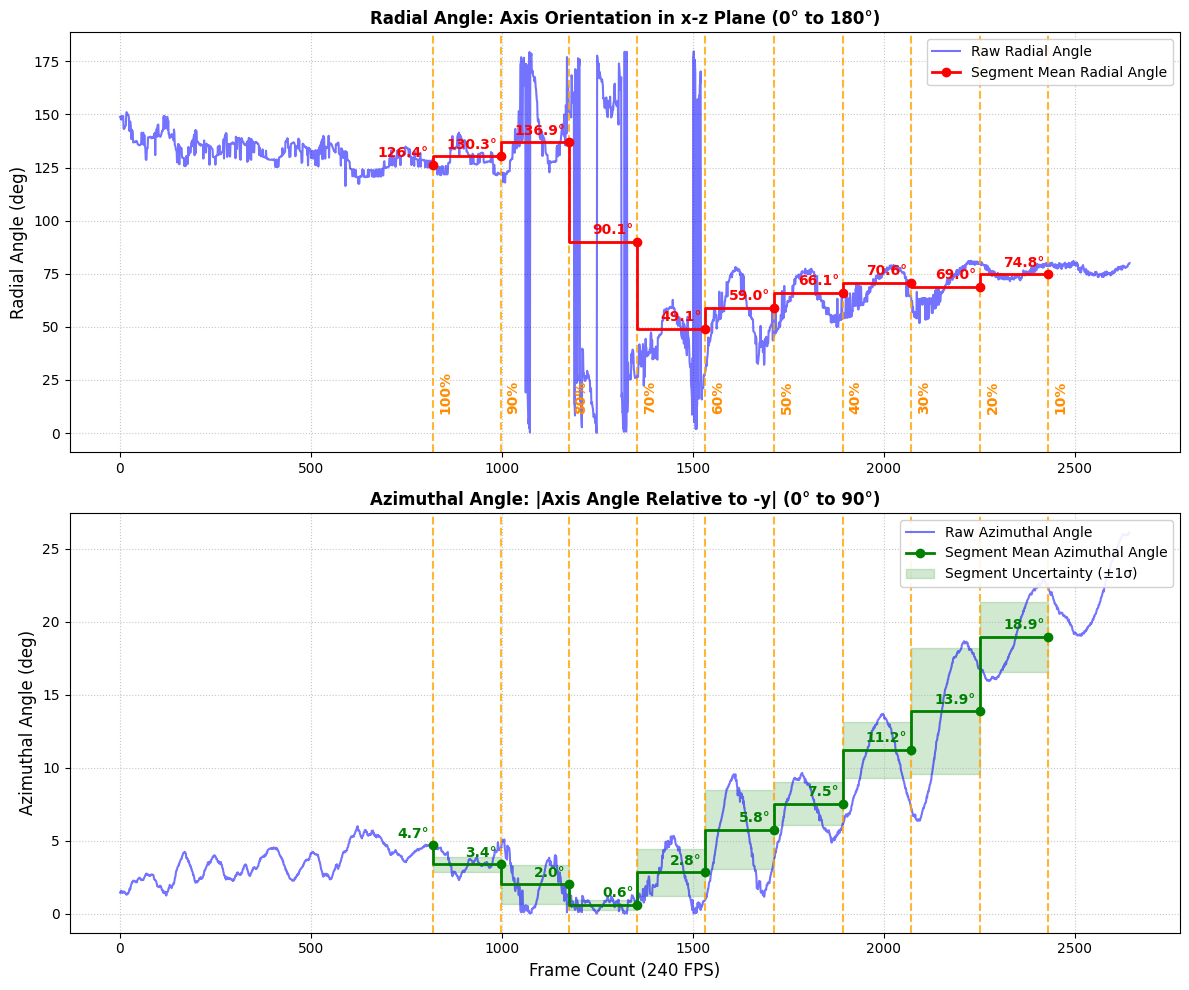

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load detections only
df = pd.read_csv(output_csv_path)
df = df[df['detected']].copy()

# Plot both angles
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# --- RADIAL ANGLE ---
mean_segment_angles = []
segment_std_angles = []
segment_var_angles = []
segment_buffer = 20

for i, time in enumerate(brightness_frames):
    seg_start = brightness_frames[i-1] + segment_buffer if i > 0 else brightness_frames[0] - 240
    seg_end = time - segment_buffer

    seg = df[(df['frame'] >= seg_start) & (df['frame'] <= seg_end)]['radial_angle_deg']
    mean_val = seg.mean()
    std_val = seg.std()
    mean_segment_angles.append(mean_val)
    segment_std_angles.append(std_val)
    print(f"Segment {i}: Frames {seg_start} to {seg_end}, Mean Radial: {mean_val:.2f}, Std: {std_val:.2f}")

ax1.plot(df['frame'], df['radial_angle_deg'], 'b-', alpha=0.55, label='Raw Radial Angle')

y_min, y_max = df['radial_angle_deg'].min(), df['radial_angle_deg'].max()
y_range = max(y_max - y_min, 1)

for i, bt in enumerate(brightness_frames):
    ax1.axvline(bt, color='orange', linestyle='--', alpha=0.8)
    percentage_str = f'{100 - i*10}%'
    ax1.text(bt + 15, y_min + y_range * 0.05, percentage_str,
             color='darkorange', rotation=90, va='bottom', ha='left',
             fontweight='bold', fontsize=10)

ax1.plot(brightness_frames, mean_segment_angles, 'ro-', drawstyle='steps-pre',
         linewidth=2, markersize=6, label='Segment Mean Radial Angle')

for bt, mean_angle in zip(brightness_frames, mean_segment_angles):
    if pd.notna(mean_angle):
        ax1.text(bt - 10, mean_angle + (y_range * 0.02), f"{mean_angle:.1f}°",
                 color='red', fontweight='bold', fontsize=10, ha='right')

ax1.set_title('Radial Angle: Axis Orientation in x-z Plane (0° to 180°)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Radial Angle (deg)', fontsize=12)
ax1.legend(loc='upper right', framealpha=0.9)
ax1.grid(True, linestyle=':', alpha=0.7)

# --- AZIMUTHAL ANGLE ---
mean_segment_angles = []
segment_std_angles = []

for i, time in enumerate(brightness_frames):
    seg_start = brightness_frames[i-1] + segment_buffer if i > 0 else brightness_frames[0] - 240
    seg_end = time - segment_buffer

    seg = df[(df['frame'] >= seg_start) & (df['frame'] <= seg_end)]['azimuthal_angle_deg']
    mean_val = seg.mean()
    std_val = seg.std()
    var_val = seg.var()
    mean_segment_angles.append(mean_val)
    segment_std_angles.append(std_val)
    segment_var_angles.append(var_val)
    print(f"Segment {i}: Mean Azimuthal: {mean_val:.2f}, Std: {std_val:.2f}, Var: {var_val:.2f}")

ax2.plot(df['frame'], df['azimuthal_angle_deg'], 'b-', alpha=0.55, label='Raw Azimuthal Angle')

y_min, y_max = df['azimuthal_angle_deg'].min(), df['azimuthal_angle_deg'].max()
y_range = max(y_max - y_min, 1)

for i, bt in enumerate(brightness_frames):
    ax2.axvline(bt, color='orange', linestyle='--', alpha=0.8)

ax2.plot(brightness_frames, mean_segment_angles, 'go-', drawstyle='steps-pre',
         linewidth=2, markersize=6, label='Segment Mean Azimuthal Angle')

azim_lower = [m - s if pd.notna(m) and pd.notna(s) else float('nan') for m, s in zip(mean_segment_angles, segment_std_angles)]
azim_upper = [m + s if pd.notna(m) and pd.notna(s) else float('nan') for m, s in zip(mean_segment_angles, segment_std_angles)]
ax2.fill_between(brightness_frames, azim_lower, azim_upper, step='pre',
                 color='green', alpha=0.18, label='Segment Uncertainty (±1σ)')

for bt, mean_angle in zip(brightness_frames, mean_segment_angles):
    if pd.notna(mean_angle):
        ax2.text(bt - 10, mean_angle + (y_range * 0.02), f"{mean_angle:.1f}°",
                 color='green', fontweight='bold', fontsize=10, ha='right')

ax2.set_title('Azimuthal Angle: |Axis Angle Relative to -y| (0° to 90°)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Frame Count (240 FPS)', fontsize=12)
ax2.set_ylabel('Azimuthal Angle (deg)', fontsize=12)
ax2.legend(loc='upper right', framealpha=0.9)
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()